# Shallow water in 1-D

The smallest complete Zoomy run: derive a model, freeze it, pick a scheme, solve,
plot. About twenty lines of actual work.

Shallow water is **not** typed out by hand here — it is the level-0 member of the
Shallow Moment family, `SME(level=0)`. Everything on this page is symbolic until
the last step.

See [Model](../../../authoring/model.md) for the authoring surface this uses.

## 1. The model

Three ingredients: the family, the physics closures, and the run conditions
(boundary + initial). Nothing here is numerical yet — no mesh, no timestep.

In [1]:
import numpy as np

from zoomy_core.model.models import SME, Newtonian, NavierSlip, StressFree
import zoomy_core.model.boundary_conditions as BC
import zoomy_core.model.initial_conditions as IC

model = SME(
    level=0,                                   # level 0 == shallow water
    closures=[Newtonian(), NavierSlip(), StressFree()],
    boundary_conditions=BC.BoundaryConditions([
        BC.Wall(tag="left"),                   # closed box: nothing enters or leaves
        BC.Wall(tag="right"),
    ]),
    initial_conditions=IC.RP(                  # dam break: h = 2 on the left, 1 on the right
        high=lambda n: np.array([0.0, 2.0] + [0.0] * (n - 2)),
        low=lambda n: np.array([0.0, 1.0] + [0.0] * (n - 2)),
        jump_position_x=5.0,
    ),
)

## 2. Freeze it into operators

`SystemModel.from_model` walks the model once and freezes the operator matrices.
**Print it before running anything** — the operator slots are the cheapest bug
detector in the framework. An empty `hydrostatic_pressure` on a free-surface
model, or an empty non-conservative matrix, is visible here in seconds.

In [2]:
from zoomy_core.systemmodel import SystemModel

sm = SystemModel.from_model(model)

# Display, do NOT print: describe() has a _repr_markdown_ that renders the
# operator matrices as real LaTeX. print() would dump the raw markup.
sm.describe()

**SystemModel** — 3 equations, 1 spatial dimension

**Parameters:** $g = 9.81$, $\rho = 1.0$, $\nu = 0.0$, $\lambda_{s} = 0.0$, $e_{x} = 0.0$

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - \nabla\cdot\!\big(A(Q)\,\nabla Q\big) - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}b\\h\\q_{0}\end{matrix}\right]
$$

**Auxiliary $Q_{aux}$:**

$$
\left[\begin{matrix}dq0dx\\dhdx\\dbdx\end{matrix}\right]
$$

**Mass matrix $M$:**

$$
\left[\begin{matrix}1 & 0 & 0\\0 & 1 & 0\\0 & 0 & 1\end{matrix}\right]
$$

**Flux $F$:**

$$
\left[\begin{matrix}0\\q_{0}\\\frac{q_{0}^{2}}{h}\end{matrix}\right]
$$

**Hydrostatic pressure $P$:**

$$
\left[\begin{matrix}0\\0\\\frac{g h^{2}}{2}\end{matrix}\right]
$$

**Diffusive flux $A$ $= 0$**

**NCP $B$:**

$$
\left[\begin{matrix}0 & 0 & 0\\0 & 0 & 0\\g h & 0 & 0\end{matrix}\right]
$$

**Source $S$ (implicit):**

$$
\left[\begin{matrix}0\\0\\e_{x} g h - \frac{\lambda_{s} q_{0}}{h \rho}\end{matrix}\right]
$$

**Operations:** from_model

Note `sm.aux_state`: the spatial derivatives (`dhdx`, `dq0dx`, `dbdx`) were
discovered and registered automatically. You never write a finite-difference
stencil — the solver fills them in one least-squares gradient pass per step.

In [3]:
print("state    ", [str(s) for s in sm.state])
print("aux state", [str(s) for s in sm.aux_state])

state     ['b', 'h', 'q_0']
aux state ['dq0dx', 'dhdx', 'dbdx']


## 3. Add the numerics

`NumericalSystemModel` is the SystemModel plus the scheme choices. Defaults are
sensible (`NonconservativeRusanov`, first order); we spell out the reconstruction
to show where that knob lives.

In [4]:
from zoomy_core.numerics import NumericalSystemModel, ReconstructionSpec

sm.aux_initial_conditions = IC.Constant(constants=lambda n: np.zeros(n))

nsm = NumericalSystemModel.from_system_model(
    sm, reconstruction=ReconstructionSpec(order=1))

## 4. Solve

A 50-cell mesh on `x in [0, 10]`, adaptive timestep at CFL 0.9, to `t = 0.5`.

In [5]:
from zoomy_core.mesh import BaseMesh
from zoomy_core.fvm.solver_numpy import HyperbolicSolver
from zoomy_core.fvm import timestepping

mesh = BaseMesh.create_1d(domain=(0.0, 10.0), n_inner_cells=50)

solver = HyperbolicSolver(time_end=0.5,
                          compute_dt=timestepping.adaptive(CFL=0.9))
Q, Qaux = solver.solve(mesh, nsm, write_output=False)

Q = np.asarray(Q[:, :mesh.n_inner_cells], dtype=float)
b, h, q = Q[0], Q[1], Q[2]
print(f"h range   : {h.min():.6f} .. {h.max():.6f}")


2026-07-22 17:02:00.334 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 10, time: 0.186619, dt: 0.017949, next write at time: 0.500000


2026-07-22 17:02:00.363 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 20, time: 0.364917, dt: 0.017777, next write at time: 0.500000


2026-07-22 17:02:00.386 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1295 - Finished simulation with in 0.078 seconds


## 5. Plot

`zoomy_plotting` is the house style — a case never hand-rolls its own styling.

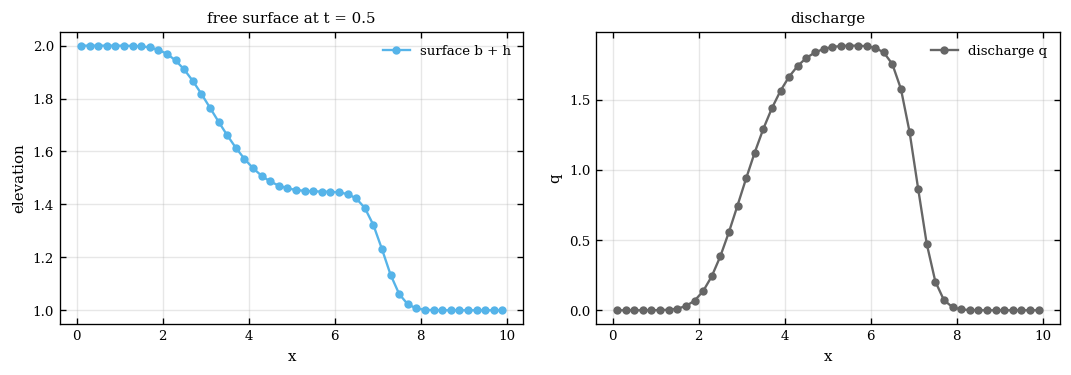

In [7]:
import matplotlib.pyplot as plt
import zoomy_plotting as zp

x = mesh.cell_centers_computed()[0][:mesh.n_inner_cells]
order = np.argsort(x)

with zp.apply_style():
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.0, 3.2))
    zp.line_plot(ax0, [
        {"x": x[order], "y": (b + h)[order], "label": "surface b + h", "role": "water"},
    ], xlabel="x", ylabel="elevation", title=f"free surface at t = {solver.time_end}")
    zp.line_plot(ax1, [
        {"x": x[order], "y": q[order], "label": "discharge q", "role": "reference"},
    ], xlabel="x", ylabel="q", title="discharge")
    for ax in (ax0, ax1):
        ax.legend()
    fig.tight_layout()